In [2]:
from diffrax import diffeqsolve, ODETerm,VirtualBrownianTree,MultiTerm,ControlTerm
from jax.scipy.stats import norm, poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

"If 40% of ensemble members predict rain the probability of rain should be 40%. "

Suppose we have an ensemble forecast $\{X_{i}\}_{i}^{N_{\text{ens}}} \sim \mathcal{N}(\mu,\sigma)$ with real value ${V} \sim \mathcal{N}(0,1)$. 

Rank all $N_{ens}$ values. 

$$
X_{1} < X_{2} < \dots <X_{n_\text{ens}}
$$

Then find 
$$
X_{i-1} < V < X_{i}. 
$$

Add $1$ to this rank, so we have $n_{\text{ens}} + 1$ ranks. Repeat for many forecasts. 

In [13]:
'''Baseline Normal Distribution'''

rng_key = jax.random.key(100)

def get_rank_histogram(truth,ensemble): 
    obs = truth
    ens = ensemble

    is_smaller = ens < obs
    ranks = jnp.sum(is_smaller,axis = 0)
    return ranks

rng_key,truth_key = jax.random.split(rng_key)

num_truth_points = 10_000
num_ensemble_members = 20
mu = 0.
sigma = 1.0

V = jax.random.normal(truth_key, shape = (num_truth_points,))
forecast_key, rng_key = jax.random.split(rng_key)
forecast = mu + sigma * jax.random.normal(forecast_key, shape  = (num_ensemble_members, num_truth_points))

norm_ranks = get_rank_histogram(V,forecast)

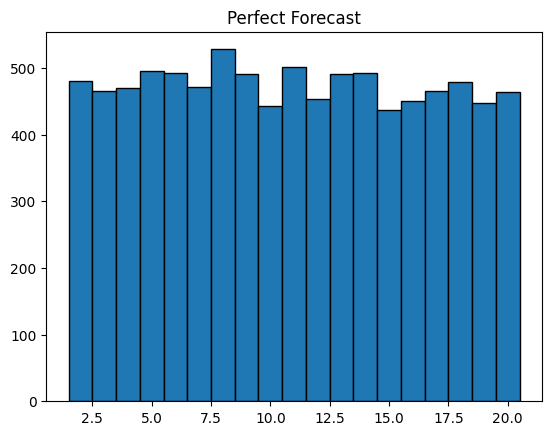

In [14]:
plt.title('Perfect Forecast')
plt.hist(norm_ranks,bins=jnp.arange(num_ensemble_members) + 2 - 0.5, edgecolor='black')
plt.show()

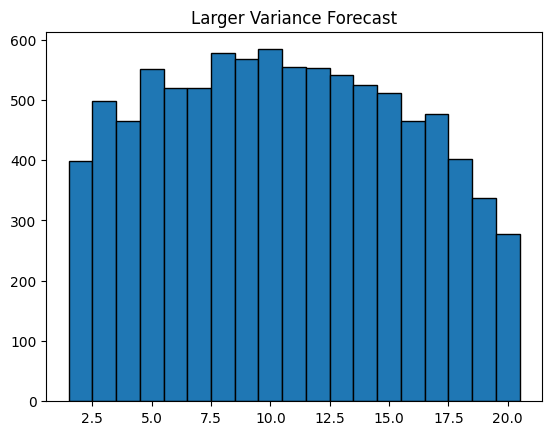

In [19]:
mu = 0.
sigma = 1.2

forecast_key, rng_key = jax.random.split(rng_key)
forecast = mu + sigma * jax.random.normal(forecast_key, shape  = (num_ensemble_members, num_truth_points))

norm_ranks = get_rank_histogram(V,forecast)

plt.title('Larger Variance Forecast')
plt.hist(norm_ranks,bins=jnp.arange(num_ensemble_members) + 2 - 0.5, edgecolor='black')
plt.show()

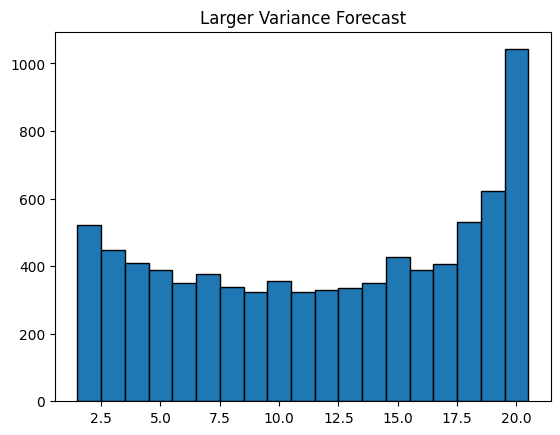

In [21]:
mu = 0.
sigma = 0.7

forecast_key, rng_key = jax.random.split(rng_key)
forecast = mu + sigma * jax.random.normal(forecast_key, shape  = (num_ensemble_members, num_truth_points))

norm_ranks = get_rank_histogram(V,forecast)

plt.title('Larger Variance Forecast')
plt.hist(norm_ranks,bins=jnp.arange(num_ensemble_members) + 2 - 0.5, edgecolor='black')
plt.show()

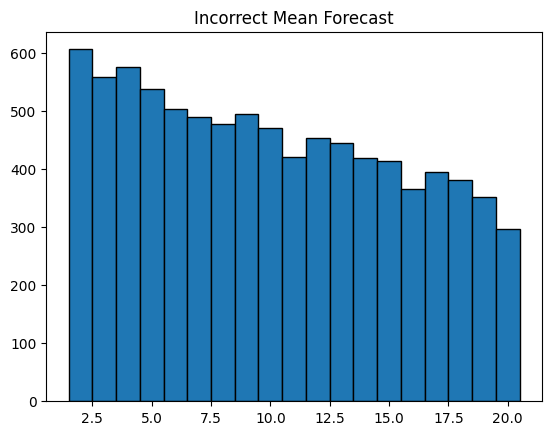

In [23]:
mu = 0.2
sigma = 1.0

forecast_key, rng_key = jax.random.split(rng_key)
forecast = mu + sigma * jax.random.normal(forecast_key, shape  = (num_ensemble_members, num_truth_points))

norm_ranks = get_rank_histogram(V,forecast)

plt.title('Incorrect Mean Forecast')
plt.hist(norm_ranks,bins=jnp.arange(num_ensemble_members) + 2 - 0.5, edgecolor='black')
plt.show()